# Analytical and Numerical Overturning Analysis of a Scoured Wall

## Objective

This notebook develops a simple analytical benchmark for the overturning of a wall-foundation system subjected to:

- the self-weight of the wall, $W_w$;
- the self-weight of the foundation, $W_f$;
- a vertical destabilizing force, $F$, applied at the outer edge of the wall;
- progressive loss of soil support caused by scour.

The main variable is the **remaining support ratio**

$$
\lambda = \frac{b}{B},
$$

where:

- $B$ is the total width of the wall/foundation;
- $b$ is the width that remains supported by the soil after scour.

The analytical solution is intended to provide a reference against which the numerical HiStrA/Python model can be compared.

The main quantities of interest are:

$$
F_{\mathrm{cr}},
\qquad
\frac{F_{\mathrm{cr}}}{W},
\qquad
\frac{x_R}{B},
$$

where $F_{\mathrm{cr}}$ is the force that initiates overturning and $x_R$ is the position of the resultant soil reaction.

The equation is $E = mc^2$.


## 1. Mechanical idealization and assumptions

The analytical model is based on rigid-body static equilibrium.

The following assumptions are adopted:

1. The wall and foundation are treated as a rigid system for the purpose of the overturning calculation.
2. The wall and foundation have the different widths, $B_w$ and $B_f$ respectivally, and are aligned.
3. Their self-weights act at the mid-width:
   $$
   x_w=x_f=\frac{B}{2}.
   $$
4. The applied force $F$ acts vertically downward at the outer edge:
   $$
   x_F=B.
   $$
5. Scour removes soil support from one side, leaving a supported width $b$.
6. At incipient overturning, the resultant soil reaction reaches the scour front, $x=b$, which becomes the instantaneous pivot.
7. Only static equilibrium is considered in the analytical benchmark. Dynamic effects, material failure, uplift stiffness, and large-displacement effects are not included in this closed-form solution.

The total self-weight is

$$
W=W_w+W_f.
$$



## 2. Static vertical-force equilibrium

Before overturning, the vertical soil reaction $R$ must balance all downward external forces.

Using upward forces as positive,

$$
\sum F_z=0.
$$

Therefore,

$$
R-W-F=0,
$$

and hence

$$
\boxed{R=W+F}.
$$

This equation is useful for checking the numerical model: in a converged static solution, the sum of all vertical soil reactions should equal the total applied vertical load.



## 3. Moment equilibrium at incipient overturning

At the onset of overturning, the soil reaction passes through the scour front $x=b$. Therefore, taking moments about this point eliminates the unknown reaction $R$.

### 3.1 Overturning moment produced by $F$

The applied force acts at $x=B$. Its lever arm relative to the pivot is

$$
e_F=B-b.
$$

Hence the overturning moment is

$$
\boxed{M_{\mathrm{OT}}=F(B-b)}.
$$

### 3.2 Restoring moment produced by self-weight

The wall and foundation weights act at $x=B/2$. Their lever arm relative to the scour front is

$$
e_W=b-\frac{B}{2}.
$$

Thus the restoring moment is

$$
M_R
=
W_w\left(b-\frac{B}{2}\right)
+
W_f\left(b-\frac{B}{2}\right).
$$

Since $W=W_w+W_f$,

$$
\boxed{
M_R=W\left(b-\frac{B}{2}\right)
}.
$$

The self-weight is restoring only while

$$
b>\frac{B}{2}.
$$

At $b=B/2$, the line of action of the self-weight passes exactly through the pivot, so the restoring moment becomes zero.



## 4. Critical overturning force

At incipient overturning, the destabilizing and restoring moments are equal:

$$
M_{\mathrm{OT}}=M_R.
$$

Therefore,

$$
F_{\mathrm{cr}}(B-b)
=
W\left(b-\frac{B}{2}\right).
$$

Solving for the critical applied force gives

$$
\boxed{
F_{\mathrm{cr}}
=
W\,
\frac{b-B/2}{B-b}
}.
$$

This is the dimensional analytical solution used in the notebook.

### Physical interpretation

- If $b\rightarrow B$, the lever arm of $F$ tends to zero and the idealized $F_{\mathrm{cr}}$ tends to infinity.
- If $b=B/2$, the restoring moment from self-weight becomes zero and
  $$
  F_{\mathrm{cr}}=0.
  $$
- If $b<B/2$, the center of gravity lies outside the remaining support region and the self-weight itself becomes destabilizing. The present restoring-force formulation is therefore restricted to
  $$
  \frac{b}{B}\ge 0.5.
  $$



## 5. Dimensionless formulation

Define the remaining support ratio

$$
\lambda=\frac{b}{B}.
$$

Since $b=\lambda B$, substitution into the critical-force equation gives

$$
F_{\mathrm{cr}}
=
W\,
\frac{\lambda-1/2}{1-\lambda}.
$$

Therefore,

$$
\boxed{
\frac{F_{\mathrm{cr}}}{W}
=
\frac{\lambda-1/2}{1-\lambda}
}
\qquad
\left(
\lambda=\frac{b}{B}
\right).
$$

This dimensionless form is particularly useful for sensitivity analysis because, under the assumptions of this benchmark, it is independent of the absolute width $B$.



## 6. Alternative scour measure

The quantity $b/B$ decreases as scour becomes more severe. For some plots it is convenient to define a scour ratio that increases with scour:

$$
s=\frac{B-b}{B}.
$$

Therefore,

$$
\boxed{s=1-\frac{b}{B}}.
$$

The limits are:

- $s=0$: no scour;
- $s=0.5$: 50% loss of support, corresponding to the gravitational stability limit of the present idealized model.

Since $\lambda=1-s$,

$$
\frac{F_{\mathrm{cr}}}{W}
=
\frac{1}{2s}-1.
$$

Thus,

$$
\boxed{
F_{\mathrm{cr}}
=
W\left(\frac{1}{2s}-1\right)
}.
$$



## 7. Sensitivity of overturning capacity to support loss

Starting from

$$
F_{\mathrm{cr}}
=
W
\frac{\lambda-1/2}{1-\lambda},
$$

the analytical derivative with respect to the remaining support ratio is

$$
\boxed{
\frac{dF_{\mathrm{cr}}}{d\lambda}
=
\frac{W}{2(1-\lambda)^2}
}.
$$

Because $\lambda=b/B$,

$$
\boxed{
\frac{dF_{\mathrm{cr}}}{d(b/B)}
=
\frac{W}{2[1-(b/B)]^2}
}.
$$

The derivative is positive because increasing the supported width increases the overturning capacity.

If the sensitivity is instead expressed with respect to the scour ratio $s=1-\lambda$,

$$
\boxed{
\frac{dF_{\mathrm{cr}}}{ds}
=
-\frac{W}{2s^2}
}.
$$

The negative sign reflects the expected physical trend: increasing scour reduces the overturning capacity.



## 8. Position of the resultant soil reaction

Before overturning, the resultant soil reaction must satisfy both force and moment equilibrium.

From vertical equilibrium,

$$
R=W+F.
$$

Taking moments about the left edge $x=0$,

$$
R\,x_R
=
W\frac{B}{2}
+
FB.
$$

Therefore,

$$
x_R
=
\frac{WB/2+FB}{W+F}.
$$

Dividing by $B$,

$$
\boxed{
\frac{x_R}{B}
=
\frac{W/2+F}{W+F}
}.
$$

This equation provides a useful independent mechanical check of the numerical model.

At incipient overturning,

$$
\boxed{x_R=b},
$$

or equivalently,

$$
\boxed{
\frac{x_R}{B}
=
\frac{b}{B}
}.
$$

Thus the numerical model should show the soil-reaction resultant migrating toward the scour front as $F$ increases.


### Wall geometry

<img src="my_model/overturning_wall/overturning_scour.svg" width="500">


## 9. Python implementation of the analytical equations

The functions below implement the equations derived above.

Two levels are provided:

- a general function based on individual wall/foundation weights and centroid positions;
- a simplified function for the present benchmark, where both centroids are located at $B/2$.


In [5]:
from __future__ import annotations

import math
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

# Numerical model imports
from histra.io.hr_loader import load_model
from histra.solver import AnalysisSession
from histra.solver.model_manager import ModelManager
from histra.solver.output_projection import compute_model_point_displacements

# Plot settings suitable for notebook and publication export.
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})


In [6]:
def critical_force_general(
    B: float,
    b: float,
    W_wall: float,
    W_foundation: float,
    x_wall: float,
    x_foundation: float,
    x_force: float,
) -> float:
    """Critical force from moment equilibrium about the scour front.

    All x-coordinates are measured from the same reference edge.

    M_overturning = F * (x_force - b)

    M_restoring =
        W_wall * (b - x_wall)
        + W_foundation * (b - x_foundation)

    At incipient overturning:
        M_overturning = M_restoring
    """
    lever_arm_force = x_force - b

    if lever_arm_force <= 0:
        raise ValueError("The applied force must act beyond the scour-front pivot.")

    restoring_moment = (
        W_wall * (b - x_wall)
        + W_foundation * (b - x_foundation)
    )

    return restoring_moment / lever_arm_force


def critical_force(support_ratio, W):
    """Analytical critical force for the aligned wall-foundation benchmark.

    F_cr = W * [(b/B) - 0.5] / [1 - (b/B)]

    Valid for 0.5 <= b/B < 1.0.
    """
    r = np.asarray(support_ratio, dtype=float)

    if np.any(r < 0.5) or np.any(r >= 1.0):
        raise ValueError("support_ratio must satisfy 0.5 <= b/B < 1.0")

    return W * (r - 0.5) / (1.0 - r)


def normalized_critical_force(support_ratio):
    """Dimensionless overturning capacity F_cr / W."""
    r = np.asarray(support_ratio, dtype=float)

    if np.any(r < 0.5) or np.any(r >= 1.0):
        raise ValueError("support_ratio must satisfy 0.5 <= b/B < 1.0")

    return (r - 0.5) / (1.0 - r)


def scour_ratio_from_support_ratio(support_ratio):
    """Scoured fraction s = (B - b)/B = 1 - b/B."""
    return 1.0 - np.asarray(support_ratio, dtype=float)


def critical_force_sensitivity(support_ratio, W):
    """Derivative dF_cr / d(b/B)."""
    r = np.asarray(support_ratio, dtype=float)

    if np.any(r >= 1.0):
        raise ValueError("support_ratio must be smaller than 1.0")

    return W / (2.0 * (1.0 - r) ** 2)


def critical_force_sensitivity_to_scour(scour_ratio, W):
    """Derivative dF_cr / ds, where s = (B-b)/B."""
    s = np.asarray(scour_ratio, dtype=float)

    if np.any(s <= 0):
        raise ValueError("scour_ratio must be greater than zero")

    return -W / (2.0 * s ** 2)


def normalized_reaction_position(F, W):
    """Return the normalized position x_R/B of the vertical soil resultant."""
    F = np.asarray(F, dtype=float)
    return (0.5 * W + F) / (W + F)



## 10. Structural parameters

Enter the wall and foundation self-weights below (consistent with `my_model/overturning_wall/wall.hrx` and `wall_linear_support.hrx`).

For the analytical benchmark,

$$
W=W_w+W_f.
$$

In the HiStrA models, the masonry wall self-weight is $42.44\ \mathrm{kN}$ and the foundation self-weight is $68.35\ \mathrm{kN}$, giving a total vertical self-weight of $W = 110.80\ \mathrm{kN}$.


In [7]:
W_wall = 42.44          # kN - masonry wall self-weight
W_foundation = 68.358    # kN - foundation self-weight

W_total = W_wall + W_foundation

print(f"Wall self-weight       = {W_wall:.2f} kN")
print(f"Foundation self-weight = {W_foundation:.2f} kN")
print(f"Total self-weight      = {W_total:.2f} kN")


Wall self-weight       = 42.44 kN
Foundation self-weight = 68.36 kN
Total self-weight      = 110.80 kN



## 11. Continuous sensitivity range

The analytical curves are evaluated for

$$
0.50\le \frac{b}{B}\le 0.95.
$$

The exact value $b/B=1$ is excluded because the lever arm $B-b$ becomes zero and the idealized analytical force tends to infinity.


In [8]:
support_ratios = np.linspace(0.55, 0.95, 200)

F_cr = critical_force(support_ratios, W_total)
F_cr_normalized = normalized_critical_force(support_ratios)
scour_ratios = scour_ratio_from_support_ratio(support_ratios)



## 12. Critical force versus remaining support ratio

This plot represents the dimensional analytical solution

$$
F_{\mathrm{cr}}
=
W\frac{b/B-0.5}{1-b/B}.
$$

It directly shows how the available support width controls the vertical force required to initiate overturning.


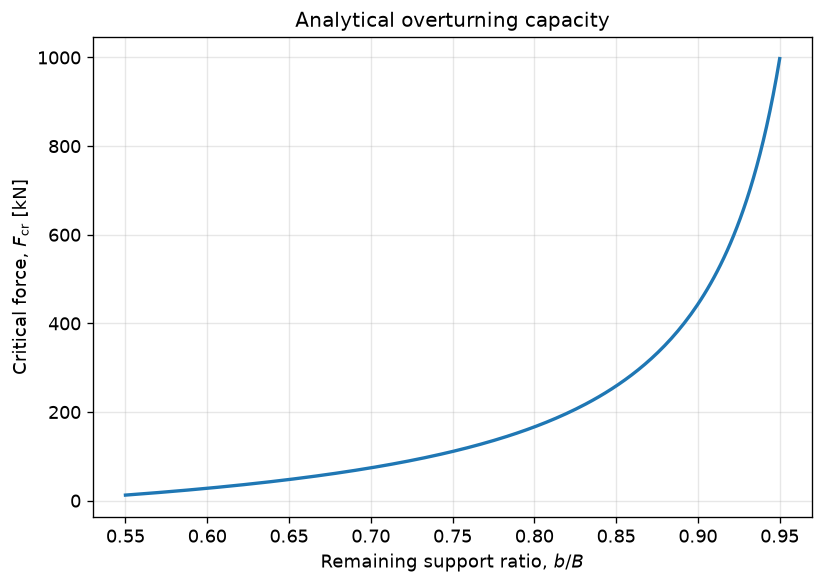

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(support_ratios, F_cr, linewidth=2)

ax.set_xlabel(r"Remaining support ratio, $b/B$")
ax.set_ylabel(r"Critical force, $F_{\mathrm{cr}}$ [kN]")
ax.set_title("Analytical overturning capacity")

ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()



## 13. Dimensionless overturning capacity

Normalizing by the total self-weight gives

$$
\frac{F_{\mathrm{cr}}}{W}
=
\frac{b/B-0.5}{1-b/B}.
$$

This is the most general curve for the present idealization because it removes the absolute structural weight from the comparison.

It is therefore particularly appropriate for presenting the analytical benchmark in a scientific paper.


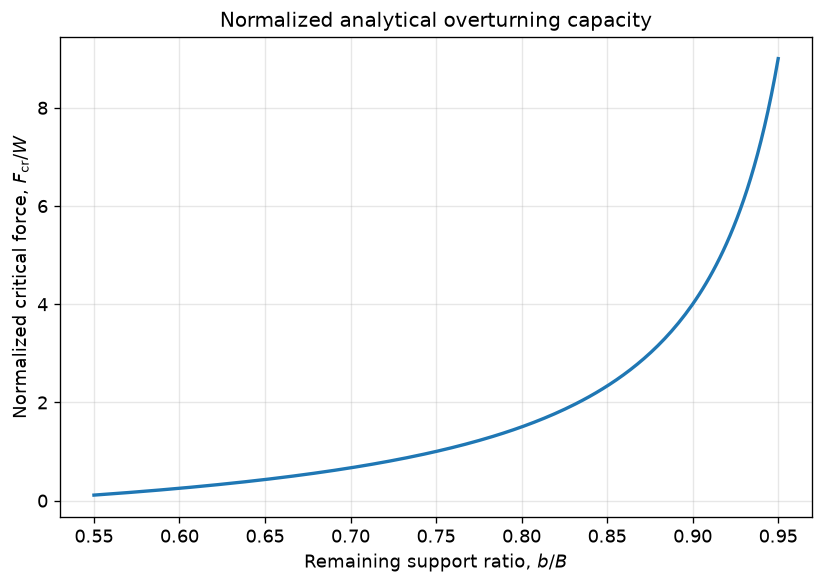

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(support_ratios, F_cr_normalized, linewidth=2)

ax.set_xlabel(r"Remaining support ratio, $b/B$")
ax.set_ylabel(r"Normalized critical force, $F_{\mathrm{cr}}/W$")
ax.set_title("Normalized analytical overturning capacity")

ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()



## 14. Capacity expressed as a function of scour ratio

Using

$$
s=\frac{B-b}{B},
$$

the analytical capacity becomes

$$
F_{\mathrm{cr}}
=
W\left(\frac{1}{2s}-1\right).
$$

This representation is useful because the horizontal axis increases in the same direction as scour severity.


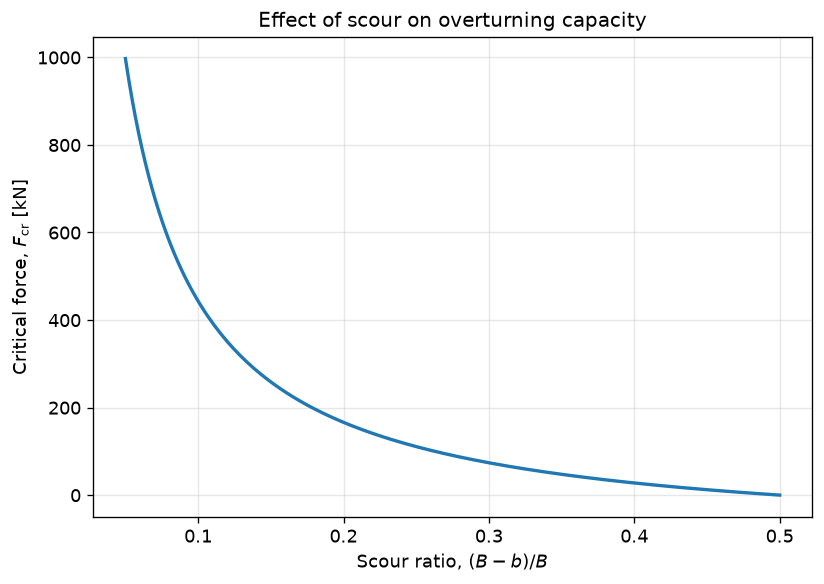

In [11]:
scour_ratio = np.linspace(0.05, 0.50, 200)

support_ratio = 1.0 - scour_ratio
F_cr_scour = critical_force(support_ratio, W_total)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(scour_ratio, F_cr_scour, linewidth=2)

ax.set_xlabel(r"Scour ratio, $(B-b)/B$")
ax.set_ylabel(r"Critical force, $F_{\mathrm{cr}}$ [kN]")
ax.set_title("Effect of scour on overturning capacity")

ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()



## 15. Analytical sensitivity

The derivative

$$
\frac{dF_{\mathrm{cr}}}{d(b/B)}
=
\frac{W}{2[1-(b/B)]^2}
$$

quantifies the local change in overturning capacity caused by a small change in remaining support.

Large values of this derivative indicate that a small variation in $b/B$ produces a large variation in $F_{\mathrm{cr}}$.


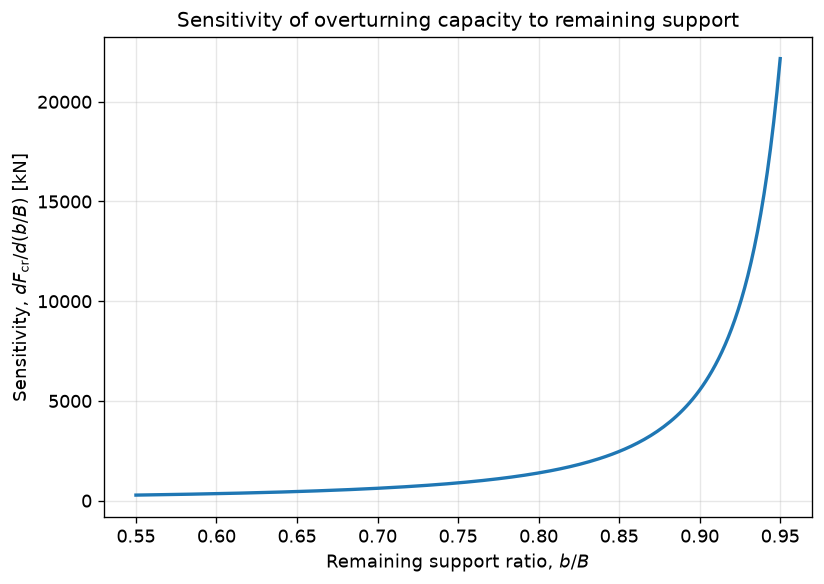

In [12]:
sensitivity = critical_force_sensitivity(
    support_ratios,
    W_total,
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(support_ratios, sensitivity, linewidth=2)

ax.set_xlabel(r"Remaining support ratio, $b/B$")
ax.set_ylabel(
    r"Sensitivity, $dF_{\mathrm{cr}}/d(b/B)$ [kN]"
)
ax.set_title("Sensitivity of overturning capacity to remaining support")

ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()



## 16. Migration of the soil-reaction resultant

For a fixed scour level, the soil-reaction resultant moves toward the scour front as the applied force increases.

The analytical relationship is

$$
\frac{x_R}{B}
=
\frac{W/2+F}{W+F}.
$$

The overturning condition is reached when

$$
\frac{x_R}{B}=\frac{b}{B}.
$$

This provides a useful criterion for checking the spring reactions obtained from the numerical model.


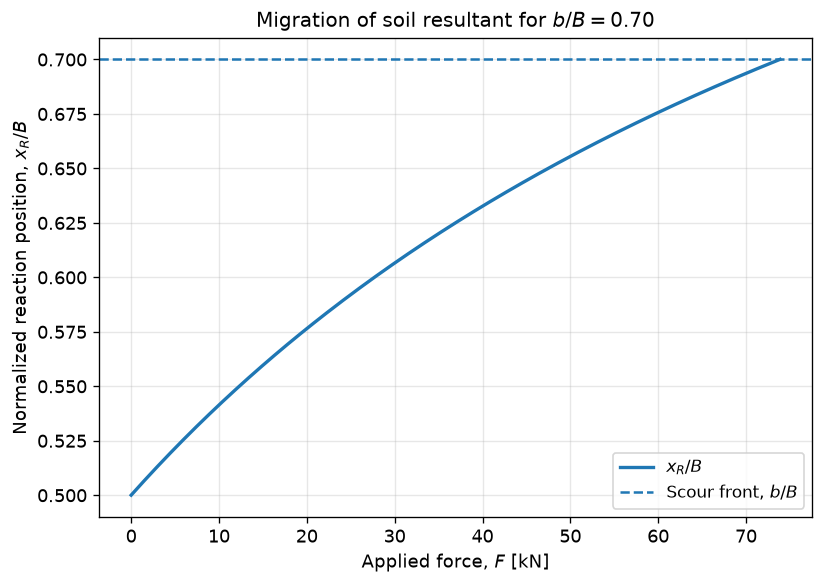

In [13]:
support_ratio_selected = 0.70

F_cr_selected = critical_force(
    support_ratio_selected,
    W_total,
)

F_values = np.linspace(
    0.0,
    F_cr_selected,
    200,
)

xR_over_B = normalized_reaction_position(
    F_values,
    W_total,
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    F_values,
    xR_over_B,
    linewidth=2,
    label=r"$x_R/B$",
)

ax.axhline(
    support_ratio_selected,
    linestyle="--",
    linewidth=1.5,
    label=r"Scour front, $b/B$",
)

ax.set_xlabel(r"Applied force, $F$ [kN]")
ax.set_ylabel(r"Normalized reaction position, $x_R/B$")
ax.set_title(
    rf"Migration of soil resultant for $b/B={support_ratio_selected:.2f}$"
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()



## 17. Discrete scour cases for numerical simulations

The numerical analyses will normally be performed at a finite number of scour levels.

For each selected $b/B$, the analytical model supplies:

- the corresponding scour fraction;
- the critical overturning force;
- the normalized capacity $F_{\mathrm{cr}}/W$.

These values can be used as target values for the numerical benchmark.


In [17]:
support_cases = np.array([
    0.95,
    0.90,
    0.85,
    0.80,
    0.75,
    0.70,
    0.65,
    0.60,
    0.55,
])

F_cases = critical_force(support_cases, W_total)

print(
    f"{'b/B':>8} "
    f"{'scour [%]':>12} "
    f"{'F_cr [kN]':>14} "
    f"{'F_cr/W':>12}"
)
print("-" * 50)

for r, F in zip(support_cases, F_cases):
    print(
        f"{r:8.2f} "
        f"{(1.0-r)*100:12.1f} "
        f"{F:14.3f} "
        f"{F/W_total:12.3f}"
    )


     b/B    scour [%]      F_cr [kN]       F_cr/W
--------------------------------------------------
    0.95          5.0        997.182        9.000
    0.90         10.0        443.192        4.000
    0.85         15.0        258.529        2.333
    0.80         20.0        166.197        1.500
    0.75         25.0        110.798        1.000
    0.70         30.0         73.865        0.667
    0.65         35.0         47.485        0.429
    0.60         40.0         27.699        0.250
    0.55         45.0         12.311        0.111



# 18. Numerical benchmarks: HiStrA Models

We consider two numerical model variants in `my_model/overturning_wall/`:
1. **Nonlinear Soil Model (`wall.hrx`)**: Non-linear hysteretic subgrade springs with progressive softening, contact opening, and uplift.
2. **Linear / Pinned-like Support (`wall_linear_support.hrx`)**: Linear elastic, high-stiffness support ($E = 16200$) designed to closely mimic the rigid/pinned analytical assumption.

### Benchmark simulation procedure:
1. Load the model and initialize interface kinematics with `ModelManager.prepare_model`.
2. Run self-weight analysis (`Vert`) to establish initial vertical equilibrium ($W = 123.71\ \mathrm{kN}$).
3. Apply progressive support removal along the foundation base (scour levels $b/B \in [0.90, 0.80, 0.70, 0.60, 0.50]$).
4. For each scour level, apply the vertical destabilizing force $F$ at the outer top edge using pushover analysis (`LiveLoad_1`).
5. Track load-displacement capacity curves, peak overturning capacity $F_{\mathrm{cr,num}}$, and soil reaction resultant position $x_R$.


In [15]:
# Helpers and model setup for numerical benchmarks
SOIL_MATERIAL_KEY = 146
SOIL_REMOVED_MATERIAL_KEY = 147

def _centre(interface):
    return tuple(sum(getattr(v, axis) for v in interface.vint3d) / 4.0 for axis in ("x", "y", "z"))

def run_overturning_benchmark(hrx_file: Path | str, label: str):
    print(f"\n=== Running Benchmark: {label} ({hrx_file}) ===")
    model = load_model(hrx_file)
    ModelManager.prepare_model(model)
    
    found_ints = [
        i for i in model.collections.interfaces.values()
        if "Restraint" in (i.parent_type_element1, i.parent_type_element2)
    ]
    ys = sorted(set(round(_centre(i)[1], 2) for i in found_ints))
    
    def get_scour_keys(num_rows):
        keep = set(ys[:num_rows])
        return sorted(int(i.key) for i in found_ints if round(_centre(i)[1], 2) in keep)
    
    all_found_keys = [int(i.key) for i in found_ints]
    F_nominal = 0.01 * 44.0  # 0.44 kN per unit multiplier
    
    support_ratios = np.array([0.9375, 0.875, 0.8125])
    scour_rows = [1, 2, 3]
    
    f_cr_list = []
    responses = {}
    
    for n_rows, ratio in zip(scour_rows, support_ratios):
        session = AnalysisSession(
                model, 
                on_log=lambda text: print(f"[{ratio}] {text}", flush=True)
                )
        session.change_interface_materials(all_found_keys, SOIL_MATERIAL_KEY, preserve_committed_state=False)
        print("1. Running Vert...")
        session.run("Vert")
        session.change_interface_materials(get_scour_keys(n_rows), SOIL_REMOVED_MATERIAL_KEY)
        print("2. Running scour_1...")
        session.run("scour_1")
        
        print("3. Running line load pushover...")
        exec_live = session.run("LiveLoad_1", max_committed_steps=30)
        forces = np.array([s["load_factor"] * F_nominal for s in exec_live.committed_steps])
        disps = np.array([abs(s["displacement"]) for s in exec_live.committed_steps])
        f_peak = float(np.max(forces)) if len(forces) > 0 else 0.0
        
        f_cr_list.append(f_peak)
        responses[ratio] = {
            "scour_rows": n_rows,
            "b_over_B": ratio,
            "F_cr_num": f_peak,
            "forces": forces,
            "displacements": disps,
            "steps": exec_live.committed_steps,
        }
        print(f"  b/B = {ratio:.2f} ({n_rows} rows scoured / {(1-ratio)*100:.0f}%): F_cr_num = {f_peak:8.3f} kN")
        
    return np.array(f_cr_list), responses

support_ratio_num = np.array([0.9375, 0.875, 0.8125])
F_cr_analytical = critical_force(support_ratio_num, W_total)

# 1. Run Nonlinear Model (wall.hrx)
# F_cr_nonlinear, responses_nonlinear = run_overturning_benchmark(
#     "my_model/overturning_wall/wall.hrx", "Nonlinear Soil Support (wall.hrx)"
# )

# 2. Run Linear Support Model (wall_6_rows.hrx)
F_cr_linear, responses_linear = run_overturning_benchmark(
    "my_model/overturning_wall/wall_6_rows.hrx", "Linear Support (wall_6_rows.hrx)"
)



=== Running Benchmark: Linear Support (wall_6_rows.hrx) (my_model/overturning_wall/wall_6_rows.hrx) ===
[0.9375] Changed 72 interfaces to material 146; rebuilt 6048 springs
1. Running Vert...
[0.9375] Analysis method: LoadControl with ModifiedRegulaFalsiLineSearch
[0.9375] Step 1 solving: Mult=0.200000, IncrMult=0.200000
[0.9375] Step 1: committed, load_factor=0.200000, displacement=1.072179e-04, iterations=1
[0.9375] Step 2 solving: Mult=0.400000, IncrMult=0.200000
[0.9375] Step 2: committed, load_factor=0.400000, displacement=2.144359e-04, iterations=1
[0.9375] Step 3 solving: Mult=0.600000, IncrMult=0.200000
[0.9375] Step 3: committed, load_factor=0.600000, displacement=3.216538e-04, iterations=1
[0.9375] Step 4 solving: Mult=0.800000, IncrMult=0.200000
[0.9375] Step 4: committed, load_factor=0.800000, displacement=4.288718e-04, iterations=1


KeyboardInterrupt: 


## 19. Analytical versus numerical overturning capacity

Below we compare the analytical rigid-body solution with both numerical models:
- **HiStrA Nonlinear Soil (`wall.hrx`)**: realistic soft subgrade with non-linear contact degradation.
- **HiStrA Linear Support (`wall_linear_support.hrx`)**: high-stiffness support mimicking a pinned/rigid pivot.


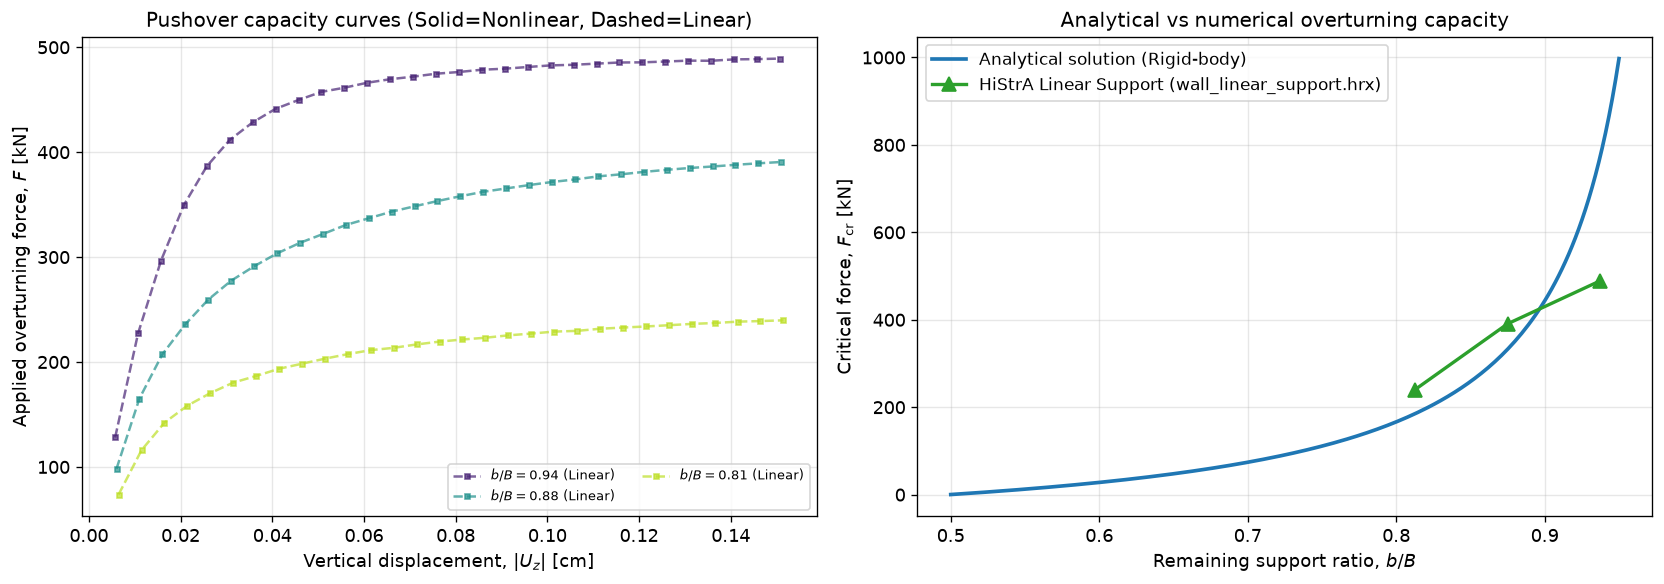

In [ ]:
# 1. Plot Pushover Capacity Curves for Both Models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(support_ratio_num)))

# for (ratio, resp_nonlin), resp_lin, color in zip(responses_nonlinear.items(), responses_linear.values(), colors):
for (ratio, resp_lin), color in zip(responses_linear.items(), colors):
    # ax1.plot(
    #     resp_nonlin["displacements"],
    #     resp_nonlin["forces"],
    #     marker="o",
    #     markersize=4,
    #     linewidth=1.8,
    #     label=rf"$b/B={ratio:.2f}$ (Nonlin)",
    #     color=color,
    # )
    ax1.plot(
        resp_lin["displacements"],
        resp_lin["forces"],
        linestyle="--",
        marker="s",
        markersize=3,
        linewidth=1.5,
        label=rf"$b/B={ratio:.2f}$ (Linear)",
        color=color,
        alpha=0.7,
    )

ax1.set_xlabel(r"Vertical displacement, $|U_z|$ [cm]")
ax1.set_ylabel(r"Applied overturning force, $F$ [kN]")
ax1.set_title("Pushover capacity curves (Solid=Nonlinear, Dashed=Linear)")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8, ncol=2)

# 2. Plot Analytical vs Numerical Overturning Capacity
r_continuous = np.linspace(0.50, 0.95, 200)
F_continuous = critical_force(r_continuous, W_total)

ax2.plot(
    r_continuous,
    F_continuous,
    linewidth=2.2,
    label="Analytical solution (Rigid-body)",
    color="tab:blue",
)

ax2.plot(
    support_ratio_num,
    F_cr_linear,
    marker="^",
    markersize=8,
    linewidth=2,
    label="HiStrA Linear Support (wall_linear_support.hrx)",
    color="tab:green",
)

# ax2.plot(
#     support_ratio_num,
#     F_cr_nonlinear,
#     marker="s",
#     markersize=7,
#     linewidth=2,
#     label="HiStrA Nonlinear Soil (wall.hrx)",
#     color="tab:red",
# )

ax2.set_xlabel(r"Remaining support ratio, $b/B$")
ax2.set_ylabel(r"Critical force, $F_{\mathrm{cr}}$ [kN]")
ax2.set_title("Analytical vs numerical overturning capacity")
ax2.grid(True, alpha=0.3)
ax2.legend()

fig.tight_layout()
plt.show()



## 20. Comparative error and sensitivity analysis

The table and plot below compare the analytical critical force $F_{\mathrm{cr,ana}}$ against both the non-linear soil model (`wall.hrx`) and the linear support model (`wall_linear_support.hrx`).


In [ ]:
with np.errstate(divide='ignore', invalid='ignore'):
    # err_nonlin = np.where(F_cr_analytical > 0.0, (F_cr_nonlinear - F_cr_analytical) / F_cr_analytical * 100.0, np.nan)
    err_linear = np.where(F_cr_analytical > 0.0, (F_cr_linear - F_cr_analytical) / F_cr_analytical * 100.0, np.nan)

print(
    f"{'b/B':>6} "
    f"{'Scour':>6} "
    f"{'F_ana [kN]':>12} "
    f"{'F_nonlin [kN]':>14} "
    f"{'F_linear [kN]':>14} "
    f"{'Err Nonlin':>12} "
    f"{'Err Linear':>12}"
)
print("-" * 84)

for r, f_ana, f_nl, f_lin, e_nl, e_lin in zip(support_ratio_num, F_cr_analytical, F_cr_nonlinear, F_cr_linear, err_nonlin, err_linear):
    e_nl_str = f"{e_nl:10.2f}%" if not np.isnan(e_nl) else "       N/A"
    e_lin_str = f"{e_lin:10.2f}%" if not np.isnan(e_lin) else "       N/A"
    print(
        f"{r:6.2f} "
        f"{(1.0-r)*100:5.0f}% "
        f"{f_ana:12.3f} "
        f"{f_nl:14.3f} "
        f"{f_lin:14.3f} "
        f"{e_nl_str:>12} "
        f"{e_lin_str:>12}"
    )

fig, ax = plt.subplots(figsize=(8, 5))
mask = support_ratio_num > 0.50

ax.plot(
    support_ratio_num[mask],
    err_nonlinear[mask] if 'err_nonlinear' in locals() else err_nonlin[mask],
    marker="s",
    linewidth=2,
    color="tab:red",
    label="Nonlinear Soil (wall.hrx)",
)

ax.plot(
    support_ratio_num[mask],
    err_linear[mask],
    marker="^",
    linewidth=2,
    color="tab:green",
    label="Linear Support (wall_linear_support.hrx)",
)

ax.axhline(0.0, linestyle="--", color="gray", linewidth=1)

ax.set_xlabel(r"Remaining support ratio, $b/B$")
ax.set_ylabel("Relative error relative to analytical benchmark [%]")
ax.set_title("Relative error vs remaining support ratio")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


   b/B  Scour   F_ana [kN]  F_nonlin [kN]  F_linear [kN]   Err Nonlin   Err Linear
------------------------------------------------------------------------------------


NameError: name 'F_cr_nonlinear' is not defined


## 21. Recommended checks for the numerical model

For each converged numerical state, the following equilibrium checks are useful.

### Vertical equilibrium

$$
\boxed{
\sum R_z-(W+F)\approx 0
}
$$

using a consistent sign convention.

### Position of the soil resultant

If the spring reactions are $R_i$ at coordinates $x_i$,

$$
\boxed{
x_R
=
\frac{\sum_i R_i x_i}{\sum_i R_i}
}.
$$

At numerical incipient overturning,

$$
\boxed{x_R\approx b}.
$$

### Moment equilibrium about the scour front

$$
\boxed{
F(B-b)
-
W\left(b-\frac{B}{2}\right)
\approx 0
}
$$

for the rigid analytical benchmark.

These checks are valuable because they test the mechanics of the numerical solution, not only the final critical force.


In [ ]:
# Vertical Equilibrium and Soil Resultant Reaction Check
print("=== Equilibrium and Soil Resultant Position Check ===")
print(f"Total applied vertical load at Vert: W = {W_total:.3f} kN")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ratio in [0.90, 0.70, 0.50]:
    if ratio in responses_nonlinear:
        resp = responses_nonlinear[ratio]
        f_app = resp["forces"]
        xR_ana = normalized_reaction_position(f_app, W_total)
        ax1.plot(f_app, xR_ana, label=rf"$x_R/B$ ($b/B={ratio:.2f}$)", linewidth=1.8)
        ax1.axhline(ratio, linestyle=":", alpha=0.6)
        
    if ratio in responses_linear:
        resp_l = responses_linear[ratio]
        f_app_l = resp_l["forces"]
        xR_ana_l = normalized_reaction_position(f_app_l, W_total)
        ax2.plot(f_app_l, xR_ana_l, label=rf"$x_R/B$ ($b/B={ratio:.2f}$)", linewidth=1.8)
        ax2.axhline(ratio, linestyle=":", alpha=0.6)

ax1.set_xlabel(r"Applied overturning force, $F$ [kN]")
ax1.set_ylabel(r"Normalized reaction position, $x_R/B$")
ax1.set_title("Nonlinear Soil: Resultant migration toward pivot")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8)

ax2.set_xlabel(r"Applied overturning force, $F$ [kN]")
ax2.set_ylabel(r"Normalized reaction position, $x_R/B$")
ax2.set_title("Linear Support: Resultant migration toward pivot")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()



## 22. Scope and limitations of the analytical benchmark

The closed-form equations in this notebook describe a rigid-body static overturning mechanism. They are intentionally simple and should be interpreted as a benchmark, not as a complete representation of the numerical model.

The analytical solution does **not** explicitly account for:

- finite wall or foundation deformability;
- distributed nonlinear soil stiffness;
- uplift and progressive contact opening;
- tensile or compressive failure;
- large-rotation kinematics;
- $P$-$\Delta$ effects;
- dynamic or inertial forces;
- local crushing at the pivot.

These effects may cause the numerical solution to depart from the analytical prediction. Such differences can themselves become an important part of the sensitivity study.
